In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [20]:
df = pd.read_csv('Sample-Superstore.csv', encoding='latin1')
df.columns = df.columns.str.strip()
print("All Column Names:")
for col in df.columns.tolist():
  print(f" '{col}'")
print("Dataset loaded!")
print("Total rows and columns:", df.shape)
print(df.head())

All Column Names:
 'Row ID'
 'Order ID'
 'Order Date'
 'Ship Date'
 'Ship Mode'
 'Customer ID'
 'Customer Name'
 'Segment'
 'Country'
 'City'
 'State'
 'Postal Code'
 'Region'
 'Product ID'
 'Category'
 'Sub-Category'
 'Product Name'
 'Sales'
Dataset loaded!
Total rows and columns: (9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
1       2  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
2       3  CA-2017-138688  12-06-2017  16-06-2017    Second Class    DV-13045   
3       4  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   
4       5  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    

In [21]:
df.rename(columns={
    'Sales ': 'Sales',
    'Profit ': 'Profit',
    ' Profit': 'Profit',
    ' Sales': 'Sales'
}, inplace=True)

print("Fixed! Columns now:")
print(df.columns.tolist())
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nAny Missing Values?")
print(df.isnull().sum())


Fixed! Columns now:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']
Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

Any Missing Values?
Row ID          

In [22]:
print("=====SALES SUMMARY=====")
print("Total Sales: $",round(df['Sales'].sum(), 2))
print("Total Orders: $",df['Order ID'].nunique())
print("Total Customers: $",df['Customer ID'].nunique())
print("Total Product: $",df['Product Name'].nunique())

=====SALES SUMMARY=====
Total Sales: $ 2261536.78
Total Orders: $ 4922
Total Customers: $ 793
Total Product: $ 1849


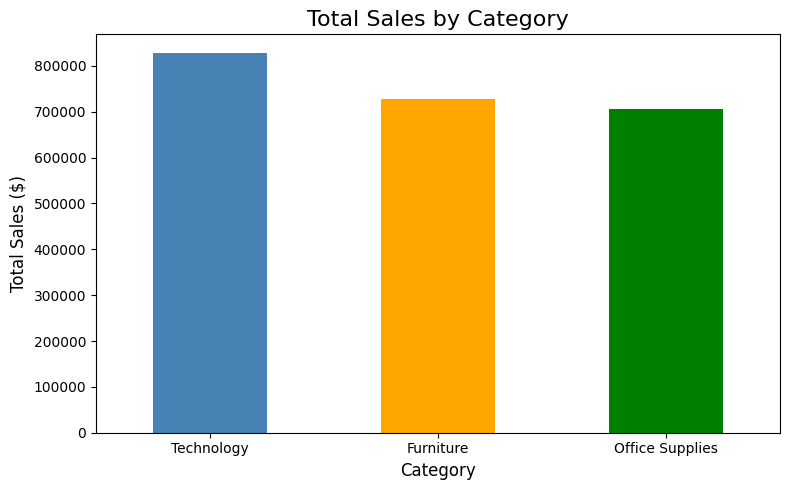

Sales by Category:
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [23]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color=['steelblue','orange','green'])
plt.title('Total Sales by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sales_by_category.png')
plt.show()

print("Sales by Category:")
print(category_sales)

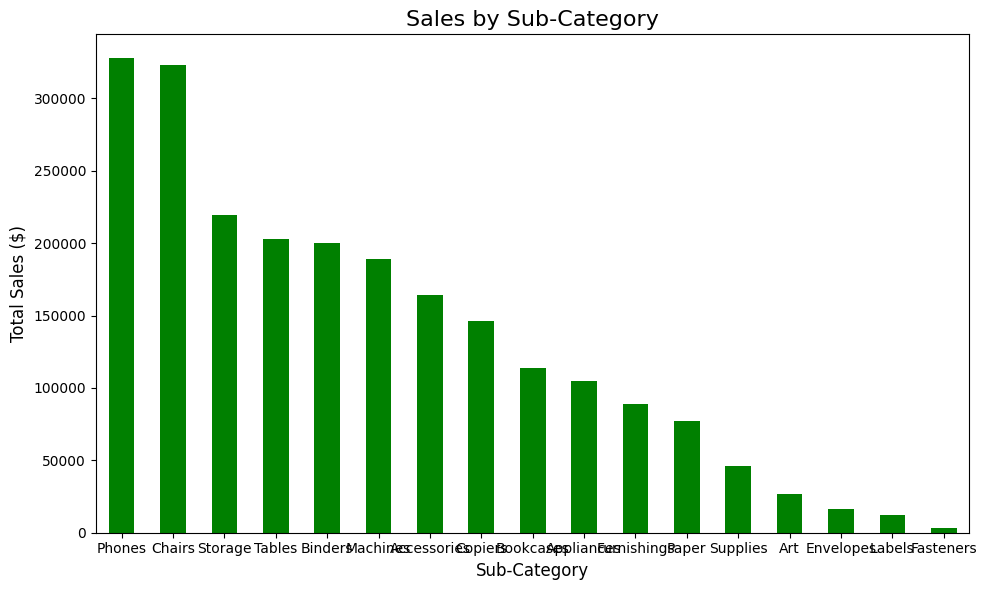

Sales by Sub-Category:
Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


In [24]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
subcategory_sales.plot(kind='bar', color='green')
plt.title('Sales by Sub-Category', fontsize=16)
plt.xlabel('Sub-Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('profit_by_subcategory.png')
plt.show()

print("Sales by Sub-Category:")
print(subcategory_sales)

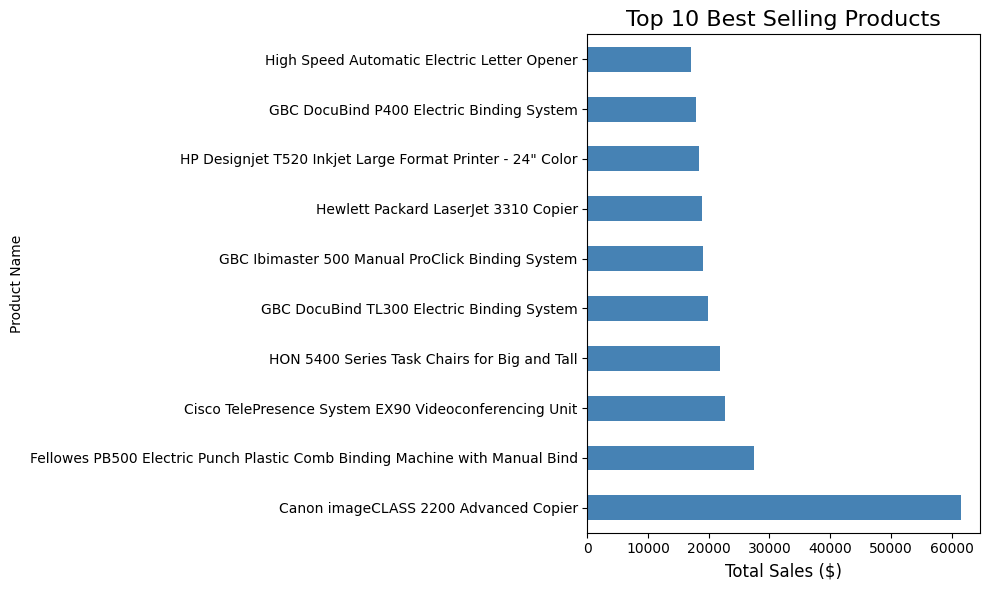

Top 10 Products:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [25]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Best Selling Products', fontsize=16)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

print("Top 10 Products:")
print(top_products)

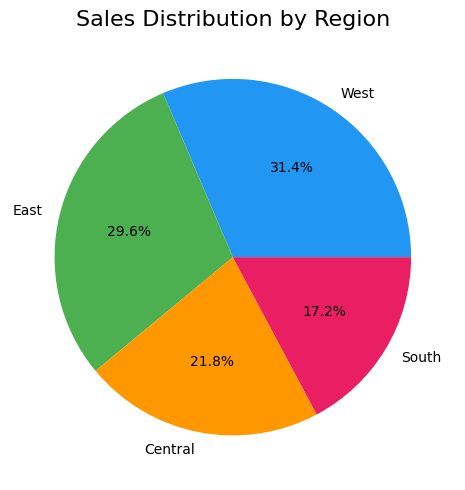

Sales by Region:
Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [26]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', colors=colors)
plt.title('Sales Distribution by Region', fontsize=16)
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.show()

print("Sales by Region:")
print(region_sales)

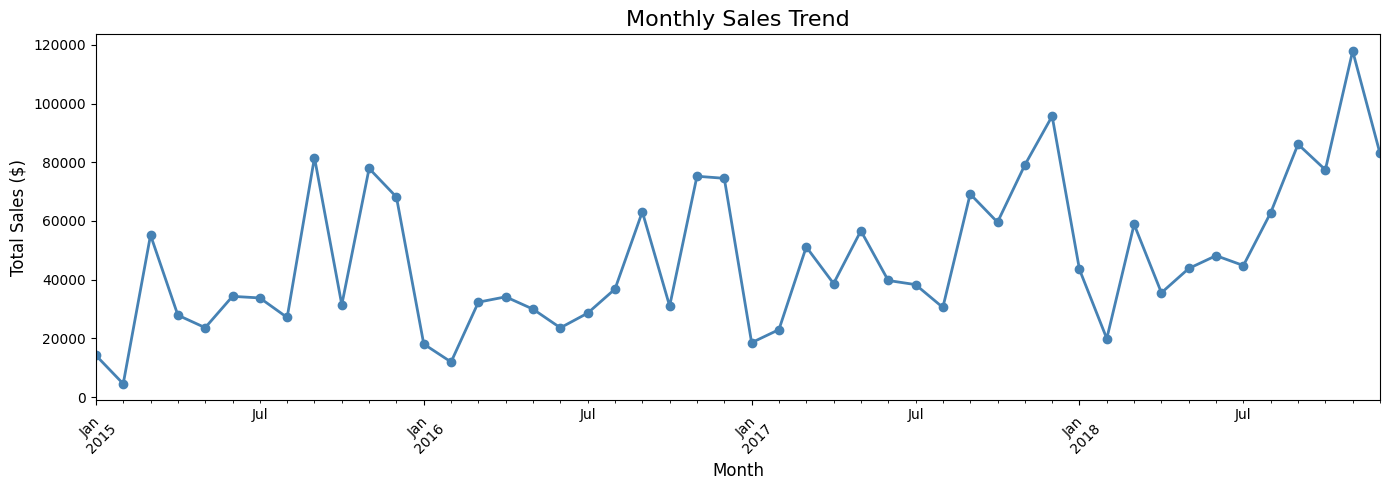

Monthly Sales Done!


In [27]:
df['Order Date'] = pd.to_datetime(df['Order Date'],dayfirst=True,errors='coerce')
df['Month-Year'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month-Year')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', color='steelblue', marker='o', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()
print("Monthly Sales Done!")

In [28]:
print("========================================")
print("       KEY BUSINESS INSIGHTS")
print("========================================")

best_category = df.groupby('Category')['Sales'].sum().idxmax()
worst_category = df.groupby('Category')['Sales'].sum().idxmax()
best_region = df.groupby('Region')['Sales'].sum().idxmax()
best_ship = df.groupby('Ship Mode')['Sales'].sum().idxmax()
best_segment = df.groupby('Segment')['Sales'].sum().idxmax()

print(f"Best Selling Category   : {best_category}")
print(f"Lowest Selling Category   : {worst_category}")
print(f"Most Profitable Region  : {best_region}")
print(f"Most Used Shipping Mode : {best_ship}")
print(f"Top Customer Segment : {best_segment}")
print("========================================")

       KEY BUSINESS INSIGHTS
Best Selling Category   : Technology
Lowest Selling Category   : Technology
Most Profitable Region  : West
Most Used Shipping Mode : Standard Class
Top Customer Segment : Consumer
